In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#get all 3 csvs and load them into a single dataframe
cities_dfs = []

df_berlin = pd.read_csv('/home/kieran/Documents/Python/sunny_day_SVI/test_svi_download/Berlin/Berlin_1276451290.csv')
df_belgrade = pd.read_csv('/home/kieran/Documents/Python/sunny_day_SVI/test_svi_download/Belgrade/Belgrade_1688374696.csv')
df_abu_dhabi = pd.read_csv('/home/kieran/Documents/Python/sunny_day_SVI/test_svi_download/Abu Dhabi/Abu-Dhabi_1784176710.csv')

cities_dfs = [df_abu_dhabi,df_berlin,df_belgrade]

df_city_metadata = pd.concat(cities_dfs,axis = 0)

In [3]:
#load in img annotation df
df_img_data = pd.read_csv('/home/kieran/Documents/Python/sunny_day_SVI/test_svi_download/test_output.csv')

In [50]:
#join dfs
df_merged_data = pd.merge(df_img_data,df_city_metadata, on = ['id'])

In [51]:
df_merged_data['shade_person_ratio'] = df_merged_data['nshade']/df_merged_data['npeople']

In [52]:
print(len(df_merged_data))

9285


In [53]:
df_merged_data.head()

,Unnamed: 0_x,id,shade_percent,npeople,nshade,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0_y,geometry,...,city_id,lat,lon,timezone,utc-offset,datetime-local,wbulb,dbulb,tsun,shade_person_ratio
0,0,1622591368219916,0.148091,0,0,1540.0,1540.0,1540,1540,POINT (54.39983904361725 24.460666289102917),...,1.784177e+09,24.460666,54.399839,Asia/Dubai,14400.0,2023-04-19 08:38:02.736000+04:00,17.610571,25.0,0.0,NaN
1,1,740795164362447,0.262546,0,0,1168.0,1168.0,1168,1168,POINT (54.388439655303955 24.4513444142558),...,1.784177e+09,24.451344,54.388440,Asia/Dubai,14400.0,2023-03-20 18:19:31.302000+04:00,18.031762,27.4,0.0,NaN
2,2,506555038688735,0.261814,3,3,NaN,NaN,2251,2251,POINT (13.397038578987122 52.5135374075582),...,1.276451e+09,52.513537,13.397039,Europe/Berlin,7200.0,2024-08-23 14:32:59.699000+02:00,16.910564,29.2,103.0,1.0
3,3,190051486318707,0.589863,1,0,NaN,NaN,773,773,POINT (20.458699464797974 44.82049621081495),...,1.688375e+09,44.820496,20.458699,Europe/Belgrade,7200.0,2020-09-16 17:07:09.523000+02:00,19.095535,30.1,0.0,0.0
4,4,1248752572805407,0.346393,0,0,NaN,NaN,2742,2742,POINT (20.476198196411133 44.81598320739997),...,1.688375e+09,44.815983,20.476198,Europe/Belgrade,7200.0,2024-07-27 17:55:08.095000+02:00,18.398876,32.0,0.0,NaN


In [54]:
print(type(df_merged_data['datetime-local'].iloc[0]))

<class 'str'>


In [55]:
df_merged_data['datetime-local'] = pd.to_datetime(df_merged_data['datetime-local'], format = 'mixed')

/tmp/ipykernel_1234113/200385023.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_merged_data['datetime-local'] = pd.to_datetime(df_merged_data['datetime-local'], format = 'mixed')


In [58]:
print(type(df_merged_data['datetime-local'].iloc[1]))

<class 'datetime.datetime'>


In [ ]:
#df_merged_data = df_merged_data.set_index('datetime-local')
#df_merged_data = df_merged_data.between_time('10:00','14:00')

In [56]:
df_merged_data = df_merged_data[(df_merged_data['datetime-local'].dt.time >= pd.to_datetime('10:00').time()) & (df_merged_data['datetime-local'].dt.time <= pd.to_datetime('14:00').time() )]

AttributeError: Can only use .dt accessor with datetimelike values

Text(0.5, 1.0, 'wet bulb temperature vs. shade usage')

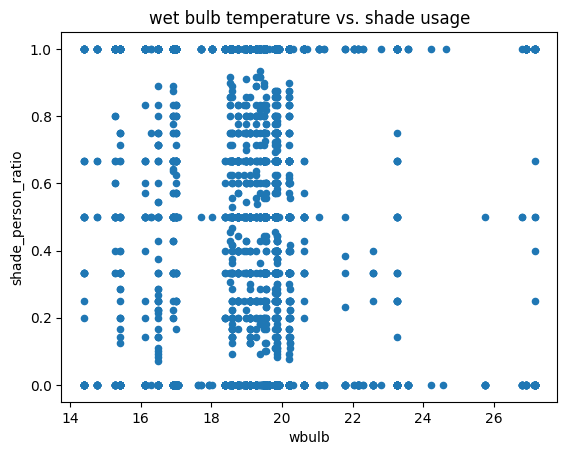

In [17]:
df_merged_data.plot(x = 'wbulb',y = 'shade_person_ratio',kind = 'scatter')
plt.title('wet bulb temperature vs. shade usage')